In [10]:
!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud

In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download nltk data files needed for this workshop
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
import pandas as pd

# URL of the dataset
url = 'https://raw.githubusercontent.com/laxmimerit/twitter-data/master/twitter4000.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)


In [13]:
# Display the first 5 rows of the DataFrame
display(df.head())

,twitts,sentiment
0,is bored and wants to watch a movie any sugge...,0
1,back in miami. waiting to unboard ship,0
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",0
3,ughhh i am so tired blahhhhhhhhh,0
4,@mandagoforth me bad! It's funny though. Zacha...,0


### Text Cleaning

Before we can perform any NLP tasks, it's crucial to clean the text data. This typically involves:
1.  Converting text to lowercase.
2.  Removing special characters, numbers, and punctuation.
3.  Removing extra whitespace.

In [15]:
import re

# Function to clean text
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers, keep spaces
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

# Apply the cleaning function to the 'twitts' column
df['cleaned_text'] = df['twitts'].apply(clean_text)

In [16]:
# Display the original and cleaned text for comparison
display(df[['twitts', 'cleaned_text']].head())

,twitts,cleaned_text
0,is bored and wants to watch a movie any sugge...,is bored and wants to watch a movie any sugges...
1,back in miami. waiting to unboard ship,back in miami waiting to unboard ship
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",misskpey awwww dnt dis brng bak memoriessss i ...
3,ughhh i am so tired blahhhhhhhhh,ughhh i am so tired blahhhhhhhhh
4,@mandagoforth me bad! It's funny though. Zacha...,mandagoforth me bad its funny though zachary q...


### Regenerating Tokenization, Stop Word Removal, and Lemmatization

To ensure all intermediate text processing columns (`processed_text` and `lemmatized_text`) are correctly created, we will re-run these steps. This addresses the `KeyError: 'lemmatized_text'`.

In [21]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Get English stop words
stop_words = set(stopwords.words('english'))

# Function to tokenize and remove stop words
def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text) # Tokenize the text
    filtered_tokens = [word for word in tokens if word not in stop_words] # Remove stop words
    return ' '.join(filtered_tokens)

# Apply the function to the cleaned_text column
df['processed_text'] = df['cleaned_text'].apply(tokenize_and_remove_stopwords)

print("Tokenization and stop word removal complete. Displaying first 5 rows with 'processed_text':")
display(df[['cleaned_text', 'processed_text']].head())

Tokenization and stop word removal complete. Displaying first 5 rows with 'processed_text':


,cleaned_text,processed_text
0,is bored and wants to watch a movie any sugges...,bored wants watch movie suggestions
1,back in miami waiting to unboard ship,back miami waiting unboard ship
2,misskpey awwww dnt dis brng bak memoriessss i ...,misskpey awwww dnt dis brng bak memoriessss th...
3,ughhh i am so tired blahhhhhhhhh,ughhh tired blahhhhhhhhh
4,mandagoforth me bad its funny though zachary q...,mandagoforth bad funny though zachary quinto t...


In [22]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to lemmatize text
def lemmatize_text(text):
    tokens = word_tokenize(text) # Tokenize again, as lemmatizer works on individual words
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized_tokens)

# Apply the function to the 'processed_text' column
df['lemmatized_text'] = df['processed_text'].apply(lemmatize_text)

print("Lemmatization complete. Displaying first 5 rows with 'lemmatized_text':")
display(df[['processed_text', 'lemmatized_text']].head())

Lemmatization complete. Displaying first 5 rows with 'lemmatized_text':


,processed_text,lemmatized_text
0,bored wants watch movie suggestions,bored want watch movie suggestion
1,back miami waiting unboard ship,back miami waiting unboard ship
2,misskpey awwww dnt dis brng bak memoriessss th...,misskpey awwww dnt dis brng bak memoriessss th...
3,ughhh tired blahhhhhhhhh,ughhh tired blahhhhhhhhh
4,mandagoforth bad funny though zachary quinto t...,mandagoforth bad funny though zachary quinto t...


### Regenerating Feature Extraction (TF-IDF) and Train-Test Split

Now that `lemmatized_text` is available, we can proceed with feature extraction and data splitting.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for demonstration

# Fit and transform the lemmatized text data
X = tfidf_vectorizer.fit_transform(df['lemmatized_text'])

print("TF-IDF matrix (X) successfully created with shape:", X.shape)

TF-IDF matrix (X) successfully created with shape: (4000, 5000)


In [24]:
from sklearn.model_selection import train_test_split

# Define target (y)
y = df['sentiment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3200, 5000)
X_test shape: (800, 5000)
y_train shape: (3200,)
y_test shape: (800,)


### Regenerating Model Training and Evaluation

With `X_train`, `X_test`, `y_train`, and `y_test` now defined, we can train and evaluate the model.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [26]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7025

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.66      0.70       422
           1       0.66      0.75      0.70       378

    accuracy                           0.70       800
   macro avg       0.71      0.71      0.70       800
weighted avg       0.71      0.70      0.70       800



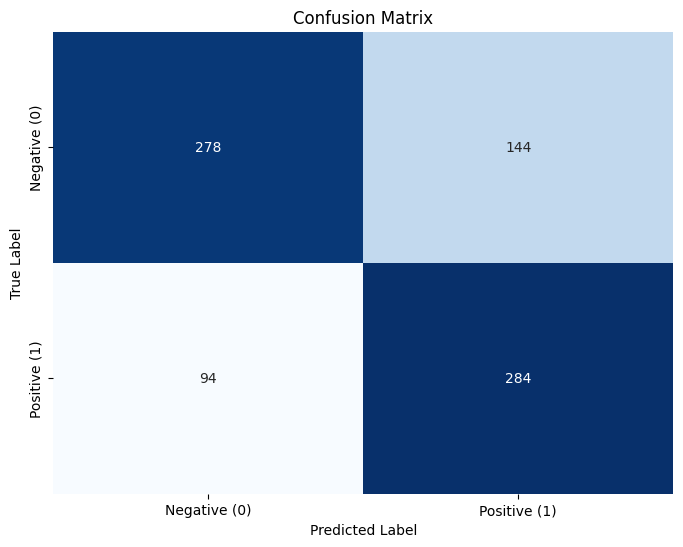

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Consolidated NLP Pipeline

Below is a consolidated set of code cells for the entire NLP pipeline. This addresses the issues with undefined variables by ensuring all steps are executed in the correct order. Please run these cells sequentially to ensure the model is trained and evaluated correctly.

In [28]:
# 1. Text Cleaning (re-using the existing function)
import re

def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers, keep spaces
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

df['cleaned_text'] = df['twitts'].apply(clean_text)
display(df[['twitts', 'cleaned_text']].head())

,twitts,cleaned_text
0,is bored and wants to watch a movie any sugge...,is bored and wants to watch a movie any sugges...
1,back in miami. waiting to unboard ship,back in miami waiting to unboard ship
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",misskpey awwww dnt dis brng bak memoriessss i ...
3,ughhh i am so tired blahhhhhhhhh,ughhh i am so tired blahhhhhhhhh
4,@mandagoforth me bad! It's funny though. Zacha...,mandagoforth me bad its funny though zachary q...


In [29]:
# 2. Tokenization and Stop Word Removal
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

df['processed_text'] = df['cleaned_text'].apply(tokenize_and_remove_stopwords)
print("Tokenization and stop word removal complete.")
display(df[['cleaned_text', 'processed_text']].head())

Tokenization and stop word removal complete.


,cleaned_text,processed_text
0,is bored and wants to watch a movie any sugges...,bored wants watch movie suggestions
1,back in miami waiting to unboard ship,back miami waiting unboard ship
2,misskpey awwww dnt dis brng bak memoriessss i ...,misskpey awwww dnt dis brng bak memoriessss th...
3,ughhh i am so tired blahhhhhhhhh,ughhh tired blahhhhhhhhh
4,mandagoforth me bad its funny though zachary q...,mandagoforth bad funny though zachary quinto t...


In [30]:
# 3. Lemmatization
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized_tokens)

df['lemmatized_text'] = df['processed_text'].apply(lemmatize_text)
print("Lemmatization complete.")
display(df[['processed_text', 'lemmatized_text']].head())

Lemmatization complete.


,processed_text,lemmatized_text
0,bored wants watch movie suggestions,bored want watch movie suggestion
1,back miami waiting unboard ship,back miami waiting unboard ship
2,misskpey awwww dnt dis brng bak memoriessss th...,misskpey awwww dnt dis brng bak memoriessss th...
3,ughhh tired blahhhhhhhhh,ughhh tired blahhhhhhhhh
4,mandagoforth bad funny though zachary quinto t...,mandagoforth bad funny though zachary quinto t...


In [31]:
# 4. Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['lemmatized_text'])
print(f"TF-IDF matrix (X) created with shape: {X.shape}")

TF-IDF matrix (X) created with shape: (4000, 5000)


In [32]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split

y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3200, 5000)
X_test shape: (800, 5000)
y_train shape: (3200,)
y_test shape: (800,)


In [33]:
# 6. Model Training (Logistic Regression)
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [34]:
# 7. Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred = log_reg_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7025

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.66      0.70       422
           1       0.66      0.75      0.70       378

    accuracy                           0.70       800
   macro avg       0.71      0.71      0.70       800
weighted avg       0.71      0.70      0.70       800



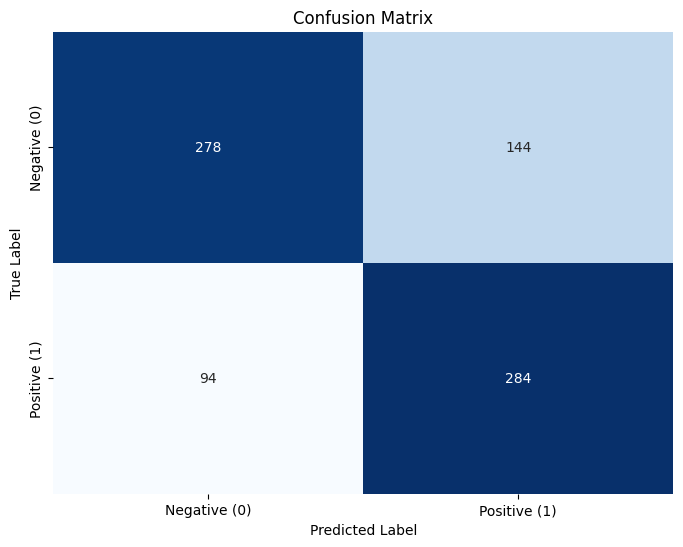

In [35]:
# 8. Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()